# **1. Load data**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import re

In [3]:
log_file_path = '/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/warmup03/log error classification/data/1_BGL_1500K_head.log'

In [4]:
# Regex pattern để parse cấu trúc log BGL
log_pattern = r'^(\S+)\s+(\d+)\s+(\d{4}\.\d{2}\.\d{2})\s+(\S+)\s+(\d{4}-\d{2}-\d{2}-\d{2}\.\d{2}\.\d{2}.\d{6})\s+(\S+)\s+(\S+)\s+(\S+)\s+(\S+)\s+(.*)$'

parsed_data = []

print("Đang đọc và parse file log...")
with open(log_file_path, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        match = re.search(log_pattern, line)
        if match:
            parsed_data.append(match.groups())

Đang đọc và parse file log...


In [5]:
# Định nghĩa tên cột
columns = [
    'Label', 'Timestamp', 'Date', 'Node', 'Time',
    'NodeRepeat', 'Type', 'Component', 'Level', 'Content'
]

# Tạo DataFrame
df = pd.DataFrame(parsed_data, columns=columns)

In [6]:
df.sample(5)

,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Level,Content
939268,-,1119695457,2005.06.25,R32-M1-N5-C:J03-U11,2005-06-25-03.30.57.487870,R32-M1-N5-C:J03-U11,RAS,KERNEL,INFO,255218536 double-hummer alignment exceptions
84176,-,1117985747,2005.06.05,R10-M0-N9-C:J09-U11,2005-06-05-08.35.47.723546,R10-M0-N9-C:J09-U11,RAS,KERNEL,INFO,generating core.7706
924708,-,1119572932,2005.06.23,R22-M1-N4-C:J14-U01,2005-06-23-17.28.52.952192,R22-M1-N4-C:J14-U01,RAS,KERNEL,INFO,3091200 double-hummer alignment exceptions
966596,-,1119715229,2005.06.25,R27-M0-N3-C:J16-U11,2005-06-25-09.00.29.007545,R27-M0-N3-C:J16-U11,RAS,KERNEL,INFO,generating core.21176
1296662,-,1120259807,2005.07.01,R24-M0-N7-C:J17-U01,2005-07-01-16.16.47.894255,R24-M0-N7-C:J17-U01,RAS,KERNEL,INFO,1146800 double-hummer alignment exceptions


# **2. Tìm hiểu dữ liệu (Exploratory Data Analysis - EDA)**

## **2.1. Kiểm tra kích thước của tập dữ liệu**

In [7]:
df.shape

(1500000, 10)

## **2.2. Tìm hiểu từng thuộc tính/cột**

### *Phân tích cột Label (đây biến mục tiêu cần phân loại)*

**[Mô tả]**
Kết quả cho thấy cột nhãn `Label` có nhiều danh mục khác nhau (các dữ liệu dạng này thường được gọi là Categorical Data).
  - **Với nhãn là `-`**: mô tả rằng hệ thống đang ở trạng thái bình thường (**Normal**).
  - **Các nhãn còn lại** là các lỗi của hệ thống (**Anomaly**).
    - KERNDTLB: Thường liên quan đến Data Translation Lookaside Buffer trong Kernel. Đây là lỗi về quản lý bộ nhớ (Memory Management), cụ thể là khi vi xử lý không tìm thấy địa chỉ vật lý tương ứng với địa chỉ ảo trong cache DTLB.
    - KERNSTOR: Liên quan đến các lỗi lưu trữ (Storage/Memory) hoặc lỗi truy cập bộ nhớ được ghi nhận bởi Kernel (ví dụ: lỗi chẵn lẻ - parity error trong cache).
    - APPSEV: Đây là các thông báo lỗi nghiêm trọng từ tầng ứng dụng (Application Severity), cho biết một tiến trình ứng dụng đã gặp sự cố không thể tự phục hồi.
    - ...

In [8]:
df['Label'].value_counts()

,count
Label,
-,1274306
KERNDTLB,152659
KERNSTOR,63488
APPREAD,5983
KERNRTSP,2586
KERNTERM,512
APPCHILD,256
APPALLOC,144
KERNMC,30


### *Phân tích cột Timestamp*

**[Mô tả]**
Giá trị trong cột Timestamp là một Unix timestamp (thời gian Unix). Nó đại diện cho số giây đã trôi qua.

In [9]:
df['Timestamp'].sample(5)

,Timestamp
693364,1118772230
104887,1117989646
919223,1119571766
1293528,1120259720
752608,1118773426


### *Phân tích cột Date và Time*

**[Mô tả]** `Date`: Ngày ghi nhận log, `Time`: Thời gian chi tiết (đến đơn vị micro giây).

In [10]:
df.head()

,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Level,Content
0,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
1,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
2,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
3,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
4,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected


/tmp/ipykernel_1686/3362588997.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d["date_hour"] = d["Time"].dt.floor("H")


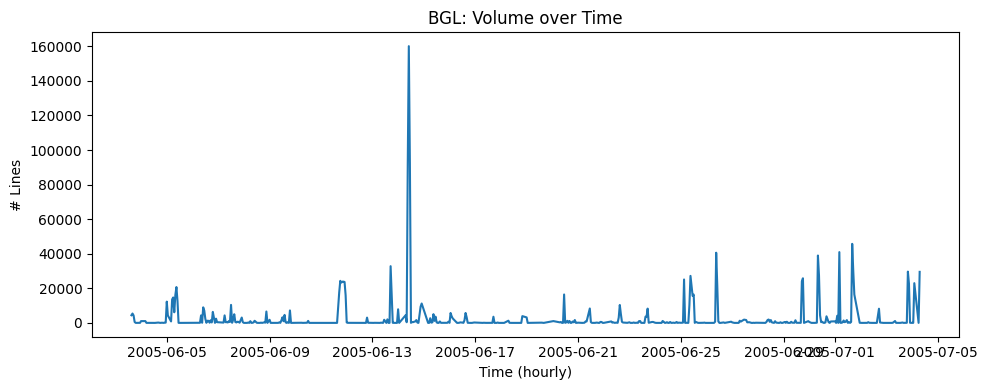

In [11]:
from typing import Optional
import pandas as pd
import matplotlib.pyplot as plt

def plot_timeline(df: pd.DataFrame, title: str, savepath: Optional[str] = None):
    d = df.copy()
    # Chuyển đổi cột Time sang datetime nếu chưa đúng định dạng
    d["Time"] = pd.to_datetime(d["Time"], format='%Y-%m-%d-%H.%M.%S.%f')

    if d["Time"].notna().sum() < 100:
        print(f"[{title}] Not enough timestamps to plot.")
        return

    d = d.dropna(subset=["Time"])
    d["date_hour"] = d["Time"].dt.floor("H")
    s = d.groupby("date_hour").size()

    plt.figure(figsize=(10, 4))
    plt.plot(s.index, s.values)
    plt.title(title)
    plt.xlabel("Time (hourly)")
    plt.ylabel("# Lines")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
    plt.show()


plot_timeline(df, "BGL: Volume over Time")

### *Phân tích cột Note và NodeRepeat*

**[Mô tả]** ID định danh vị trí phần cứng trong siêu máy tính. Hai cột chứa các thông tin giống nhau.

### *Phân tích cột Type*


**[Mô tả]** Loại bản ghi (thường là RAS)

In [ ]:
df['Type'].value_counts()

,count
Type,
RAS,1488225
NULL,11750
KERNEL,25


### *Phân tích cột Component*

**[Mô tả]** Thành phần phát ra log.

In [ ]:
df['Component'].value_counts()

,count
Component,
KERNEL,1473957
APP,13953
DISCOVERY,10593
HARDWARE,1145
LINKCARD,294
FATAL,25
MMCS,18
CMCS,12
BGLMASTER,3


### *Phân tích cột Level*

**[Mô tả]** thể hiện mức độ nghiêm trọng của sự kiện được ghi lại.

Các mức độ phổ biến như:
- INFO: Thông tin hoạt động bình thường của hệ thống. Đây là mức chiếm đa số.
- FATAL: Lỗi nghiêm trọng khiến một tiến trình hoặc thành phần hệ thống phải dừng lại ngay lập tức.
- ERROR: Các lỗi xảy ra nhưng hệ thống có thể vẫn tiếp tục chạy được (dù không ổn định).
- WARNING: Cảnh báo về các vấn đề tiềm ẩn có thể dẫn đến lỗi trong tương lai.
- SEVERE/FAILURE: Các mức độ lỗi nặng khác, tương tự như ERROR hoặc FATAL tùy theo cấu hình của hệ thống.

In [ ]:
df['Level'].value_counts()

,count
Level,
INFO,939304
FATAL,549740
WARNING,4824
SEVERE,3122
ERROR,2984
Kill,25
FAILURE,1


### *Phân tích cột Content*

**[Mô tả]** Phần quan trọng nhất trong dữ liệu log. Nó chứa thông điệp thô (raw message) do các thành phần hệ thống hoặc ứng dụng tạo ra để mô tả chi tiết sự kiện đang diễn ra.

In [ ]:
df.sample(5)

,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Level,Content
1230317,-,1120150859,2005.06.30,R05-M0-N6-C:J04-U11,2005-06-30-10.00.59.240921,R05-M0-N6-C:J04-U11,RAS,KERNEL,INFO,generating core.1135
1163605,-,1120145109,2005.06.30,R20-M1-N2-C:J02-U11,2005-06-30-08.25.09.187465,R20-M1-N2-C:J02-U11,RAS,KERNEL,INFO,generating core.5311
336530,KERNDTLB,1118552530,2005.06.11,R30-M0-N9-C:J16-U01,2005-06-11-22.02.10.809542,R30-M0-N9-C:J16-U01,RAS,KERNEL,FATAL,data TLB error interrupt
373039,KERNDTLB,1118558035,2005.06.11,R30-M0-N9-C:J16-U01,2005-06-11-23.33.55.811002,R30-M0-N9-C:J16-U01,RAS,KERNEL,FATAL,data TLB error interrupt
1111686,-,1120091442,2005.06.29,R34-M1-N4-C:J11-U01,2005-06-29-17.30.42.247959,R34-M1-N4-C:J11-U01,RAS,KERNEL,INFO,generating core.27373


## **2.3. Kiểm tra các giá trị thiếu, dư thừa**

In [ ]:
# Kiểm tra số lượng giá trị thiếu trong mỗi cột
df.isnull().sum()

,0
Label,0
Timestamp,0
Date,0
Node,0
Time,0
NodeRepeat,0
Type,0
Component,0
Level,0
Content,0


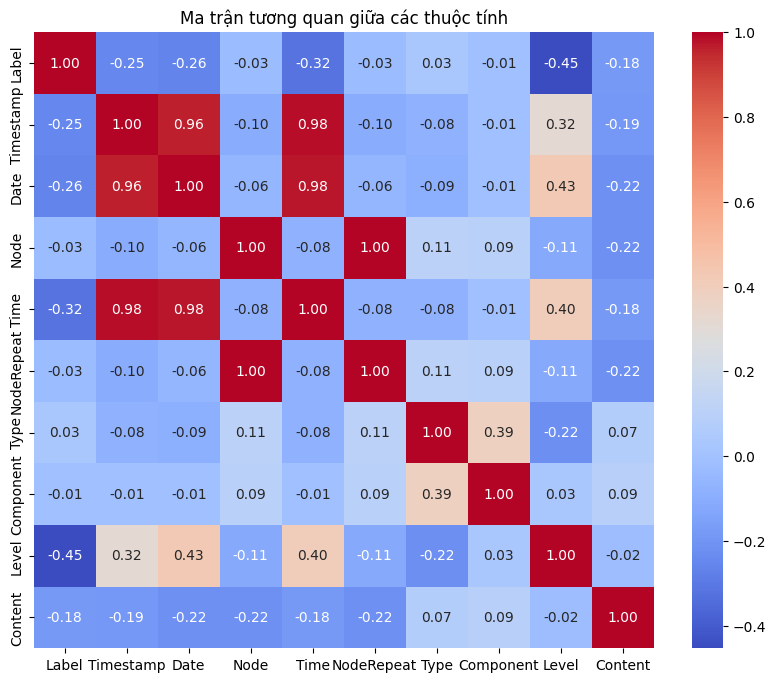

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tạo bản sao để tính toán tương quan
df_corr = df.copy()

# Mã hóa các cột dạng chuỗi thành dạng số để tính tương quan
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = df_corr[col].astype('category').cat.codes

# Tính ma trận tương quan
corr_matrix = df_corr.corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các thuộc tính')
plt.show()

Thông qua ma trận tương quan (Correlation Matrix) cho thấy một số điểm đáng chú ý về sự dư thừa dữ liệu:

  1. Timestamp, Date, và Time (Tương quan ~1.00): Nên giữ lại một cột thôi.
  2. Node và NodeRepeat (Tương quan 1.00): hai cột trùng lặp.

## **2.4. Tính toán các giá trị thống kê tóm tắt**

In [ ]:
# Tính toán thống kê tóm tắt cho các cột dữ liệu phân loại (Categorical)
categorical_stats = df.describe(include=['object'])

print("Thống kê tóm tắt cho dữ liệu phân loại:")
display(categorical_stats)

Thống kê tóm tắt cho dữ liệu phân loại:


,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Level,Content
count,1500000,1500000,1500000,1500000,1500000,1500000,1500000,1500000,1500000,1500000
unique,13,79893,32,34098,1500000,34098,3,9,7,92328
top,-,1118911758,2005.06.14,R30-M0-N9-C:J16-U01,2005-07-04-07.34.20.073893,R30-M0-N9-C:J16-U01,RAS,KERNEL,INFO,data TLB error interrupt
freq,1274306,184,381561,152271,1,152271,1488225,1473957,939304,152659


Dựa trên kết quả thống kê tóm tắt, chúng ta có một số nhận định quan trọng sau:

1. Sự mất cân bằng dữ liệu cực lớn: Nhãn phổ biến nhất là `-` (bình thường) chiếm khoảng 92.6% tổng dữ liệu (4,365,033 / 4,713,493). Điều này cần lưu ý khi xây dựng mô hình học máy.
2. Độ đa dạng của lỗi: Có 42 loại nhãn khác nhau, nhưng hầu hết các lỗi tập trung vào một số nhóm chính như KERNDTLB, KERNSTOR, APPSEV.
3. Dữ liệu trùng lặp: Cột Node có 69,252 giá trị duy nhất nhưng NodeRepeat (từ phân tích trước đó) hoàn toàn giống hệt, xác nhận việc có thể loại bỏ cột dư thừa.
4. Thông điệp Log: Có 358,356 nội dung log duy nhất. Nội dung phổ biến nhất là 'data TLB error interrupt'.

# **3. Tiền xử lý dữ liệu**

## **3.1. Loại bỏ các cột dư thừa**

In [12]:
df.sample(5)

,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Level,Content
1436302,-,1120449944,2005.07.03,R35-M1-N2-C:J09-U01,2005-07-03-21.05.44.583719,R35-M1-N2-C:J09-U01,RAS,KERNEL,INFO,generating core.10470
1461813,-,1120469582,2005.07.04,R37-M0-NB-C:J03-U01,2005-07-04-02.33.02.726786,R37-M0-NB-C:J03-U01,RAS,KERNEL,INFO,generating core.23331
880485,-,1119377760,2005.06.21,R25-M1-N2-C:J12-U01,2005-06-21-11.16.00.095475,R25-M1-N2-C:J12-U01,RAS,KERNEL,INFO,generating core.1637
1116673,-,1120091623,2005.06.29,R26-M1-ND-C:J07-U01,2005-06-29-17.33.43.550235,R26-M1-ND-C:J07-U01,RAS,KERNEL,INFO,generating core.29985
502965,KERNSTOR,1118768044,2005.06.14,R05-M1-NB-C:J07-U01,2005-06-14-09.54.04.506250,R05-M1-NB-C:J07-U01,RAS,KERNEL,FATAL,data storage interrupt


In [13]:
# Loại bỏ các cột dư thừa 'Timestamp', 'Date', 'NodeRepeat'
df = df.drop(columns=['Timestamp', 'Date', 'NodeRepeat'])

In [14]:
df.head()

,Label,Node,Time,Type,Component,Level,Content
0,-,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,RAS,KERNEL,INFO,instruction cache parity error corrected
1,-,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,RAS,KERNEL,INFO,instruction cache parity error corrected
2,-,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,RAS,KERNEL,INFO,instruction cache parity error corrected
3,-,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,RAS,KERNEL,INFO,instruction cache parity error corrected
4,-,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,RAS,KERNEL,INFO,instruction cache parity error corrected


## **3.2. Chuyển đổi nhãn**

In [15]:
# Chuyển đổi nhãn: '-' thành 0 (Normal), các giá trị khác thành 1 (Anomaly)
df['Label'] = df['Label'].apply(lambda x: 0 if x == '-' else 1)

# Kiểm tra lại phân bổ nhãn mới
print("Phân bổ nhãn sau khi chuyển đổi (0: Normal, 1: Anomaly):")
print(df['Label'].value_counts())
display(df.head())

Phân bổ nhãn sau khi chuyển đổi (0: Normal, 1: Anomaly):
Label
0    1274306
1     225694
Name: count, dtype: int64


,Label,Node,Time,Type,Component,Level,Content
0,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,RAS,KERNEL,INFO,instruction cache parity error corrected
1,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,RAS,KERNEL,INFO,instruction cache parity error corrected
2,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,RAS,KERNEL,INFO,instruction cache parity error corrected
3,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,RAS,KERNEL,INFO,instruction cache parity error corrected
4,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,RAS,KERNEL,INFO,instruction cache parity error corrected


## **3.3. Chuyển đổi cột Time sang định dạng Datetime của Pandas**

In [10]:
# Chuyển đổi cột Time sang định dạng Datetime của Pandas
# Chuỗi mẫu: 2005-06-03-15.42.50.675872 -> Format: %Y-%m-%d-%H.%M.%S.%f
df['Datetime'] = pd.to_datetime(df['Time'], format='%Y-%m-%d-%H.%M.%S.%f')

In [11]:
df = df.drop(columns=['Time'])

In [12]:
df.head()

,Label,Node,Type,Component,Level,Content,Datetime
0,0,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,2005-06-03 15:42:50.363779
1,0,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,2005-06-03 15:42:50.527847
2,0,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,2005-06-03 15:42:50.675872
3,0,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,2005-06-03 15:42:50.823719
4,0,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,2005-06-03 15:42:50.982731


# **4. Lưu dữ liệu mới sau khi xử lý**

In [33]:
from google.colab import files

# Định nghĩa tên tệp đầu ra
output_log_file = 'BGL_1500K_processed.log'

# Chuyển DataFrame thành list các chuỗi (không bao gồm header)
# map(str, row) đảm bảo mọi giá trị được chuyển sang chuỗi trước khi join bằng ' '
lines = [" ".join(map(str, row)) for row in df.values.tolist()]

# Ghi nội dung ra file
with open(output_log_file, 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))

print(f'Đã lưu thành công tệp không có header: {output_log_file}')

Đã lưu thành công tệp không có header: BGL_1500K_processed.log


In [34]:
with open(output_log_file, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5: break
        print(f"  {i+1}: {line.rstrip()}")

  1: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.363779 RAS KERNEL INFO instruction cache parity error corrected
  2: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.527847 RAS KERNEL INFO instruction cache parity error corrected
  3: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.675872 RAS KERNEL INFO instruction cache parity error corrected
  4: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.823719 RAS KERNEL INFO instruction cache parity error corrected
  5: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.982731 RAS KERNEL INFO instruction cache parity error corrected


In [35]:
# Tải tệp về máy
files.download(output_log_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>